# Experimento 2026: corrección SCCM → g/L/h de la capa CO₂

## 1 — Objetivo y alcance

Este notebook compara el resultado **LEGACY histórico congelado** con una única recalibración **SCCM_CORRECTED**. OLD se lee desde sus CSV y predicciones guardadas; no se vuelve a optimizar. NEW cambia el factor SCCM → g L⁻¹ h⁻¹ y escala sólo las cantidades dimensionalmente asociadas a esa medición, con timestamps y máscara de censura históricos congelados.

Quedan fuera: parámetros upstream (`sN`, `qXG`, `qXF`, `sG`, `sF`, `m0`), ΔN, theta upstream, estructura nutricional y ecuaciones del modelo, condiciones iniciales, LAB013–018 y la estructura causal de nutrición. La rama sintética comparte la conversión y se ejecuta como resultado secundario; el foco es mosto natural.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

os.environ["MPLBACKEND"] = "module://matplotlib_inline.backend_inline"
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
get_ipython().run_line_magic("matplotlib", "inline")

ROOT = Path.cwd().resolve()
if not (ROOT / "fermentation_model").exists():
    ROOT = next(parent for parent in Path.cwd().resolve().parents if (parent / "fermentation_model").exists())
LAB_DIR = ROOT / "fermentation_model" / "laboratory_2026"
OLD_RESULTS_DIR = LAB_DIR / "results" / "co2_matrix_cross_validation_2026"
NEW_RESULTS_DIR = LAB_DIR / "results" / "co2_matrix_cross_validation_2026_sccm_corrected"
NOTEBOOK_DIR = LAB_DIR / "notebooks"
NEW_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("JUPYTER_RUNTIME_DIR", str(NEW_RESULTS_DIR / ".jupyter_runtime"))
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))
import run_co2_matrix_cross_validation_2026 as analysis

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

## 2 — Estado reproducible

Las rutas se construyen desde el repositorio y se muestran relativas; el código no contiene rutas absolutas de Windows. Se informa el HEAD actual y se documenta por separado el commit base del experimento, sin exigir que ambos sigan siendo iguales después de futuros commits.

In [2]:
def git(*args):
    return subprocess.run(["git", *args], cwd=ROOT, check=True, text=True, capture_output=True).stdout.strip()

branch = git("branch", "--show-current")
head = git("rev-parse", "HEAD")
expected_branch = "experiment/co2-sccm-correction"
base_commit = "bdbae79a38f2331751fd785a2701b8d679b7e91a"
assert branch == expected_branch

legacy_factor = analysis.LEGACY_SCCM_CONVERSION.factor_g_l_h_per_sccm(2.0)
corrected_factor = analysis.SCCM_CORRECTED_CONVERSION.factor_g_l_h_per_sccm(2.0)
scale_ratio = corrected_factor / legacy_factor
state = pd.DataFrame([
    ["rama", branch],
    ["HEAD actual", head],
    ["commit base del experimento", base_commit],
    ["repo root", "."],
    ["baseline OLD", OLD_RESULTS_DIR.relative_to(ROOT).as_posix()],
    ["output NEW", NEW_RESULTS_DIR.relative_to(ROOT).as_posix()],
    ["MW_CO2 corrected [g/mol]", analysis.CORRECTED_CO2_MOLAR_MASS_G_MOL],
    ["Vm corrected [L/mol]", analysis.CORRECTED_MOLAR_VOLUME_L_MOL],
    ["K_CO2", analysis.CORRECTED_CO2_RESPONSE_FACTOR],
    ["volumen de referencia [L]", 2.0],
], columns=["elemento", "valor"])
display(state)

,elemento,valor
0,rama,experiment/co2-sccm-correction
1,HEAD actual,bdbae79a38f2331751fd785a2701b8d679b7e91a
2,commit base del experimento,bdbae79a38f2331751fd785a2701b8d679b7e91a
3,repo root,.
4,baseline OLD,fermentation_model/laboratory_2026/results/co2...
5,output NEW,fermentation_model/laboratory_2026/results/co2...
6,MW_CO2 corrected [g/mol],44.0095
7,Vm corrected [L/mol],24.16
8,K_CO2,0.74
9,volumen de referencia [L],2.0


## 3 — Trazabilidad del baseline histórico

**OLD = resultado histórico congelado.** Se cargan parámetros, observaciones, predicciones, métricas, validación y manifiesto ya guardados. No se llama a `fit_matrix` para OLD ni se reejecuta el notebook histórico.

In [3]:
baseline_names = [
    "analysis_manifest.json", "co2_observations_hourly.csv", "fit_parameters.csv",
    "fit_start_diagnostics.csv", "prediction_rows.csv", "batch_metrics.csv",
    "validation_summary.csv", "activation_jacobian_identifiability.csv",
]
baseline_files = pd.DataFrame({
    "archivo baseline": baseline_names,
    "existe": [(OLD_RESULTS_DIR / name).exists() for name in baseline_names],
})
baseline_files["ruta relativa"] = baseline_files["archivo baseline"].map(
    lambda name: (OLD_RESULTS_DIR / name).relative_to(ROOT).as_posix()
)
assert baseline_files["existe"].all()
old_observations = pd.read_csv(OLD_RESULTS_DIR / "co2_observations_hourly.csv")
old_fit_parameters = pd.read_csv(OLD_RESULTS_DIR / "fit_parameters.csv")
display(baseline_files)
display(old_fit_parameters.query("calibration_matrix == 'natural'").reset_index(drop=True))

,archivo baseline,existe,ruta relativa
0,analysis_manifest.json,True,fermentation_model/laboratory_2026/results/co2...
1,co2_observations_hourly.csv,True,fermentation_model/laboratory_2026/results/co2...
2,fit_parameters.csv,True,fermentation_model/laboratory_2026/results/co2...
3,fit_start_diagnostics.csv,True,fermentation_model/laboratory_2026/results/co2...
4,prediction_rows.csv,True,fermentation_model/laboratory_2026/results/co2...
5,batch_metrics.csv,True,fermentation_model/laboratory_2026/results/co2...
6,validation_summary.csv,True,fermentation_model/laboratory_2026/results/co2...
7,activation_jacobian_identifiability.csv,True,fermentation_model/laboratory_2026/results/co2...


,calibration_matrix,parameter,estimate,lower_bound,upper_bound,active_bound,relative_bound_distance
0,natural,kCO2_release_h,0.424588,0.03,25.00,False,3.940151e-01
1,natural,CO2sat_scale,0.351390,0.35,2.50,True,2.015275e-03
2,natural,O2_qmax_mg_gdw_h,0.150000,0.15,6.00,True,6.019297e-17
3,natural,O2_initial_scale,0.195400,0.05,1.50,False,4.007483e-01
4,natural,pulse_t_rise_h,64.658704,1.00,72.00,False,2.514655e-02
5,natural,pulse_activity_gain,0.250000,0.25,4.00,True,8.008566e-17
6,natural,chem_activation_start_fraction,0.735057,0.01,0.95,False,5.632878e-02
7,natural,chem_activation_duration_fraction,1.063910,0.35,2.00,False,3.621386e-01
8,natural,matrix_gain,3.115757,0.10,20.00,False,3.509152e-01


## 4 — Auditoría de la cadena SCCM

Cadena real ejecutada para el fit:

`sensor_flow_sccm` → recorte por soporte químico → `apply_sensor_zero_correction` (offset en SCCM) → conversión y clipping en g/L/h → `filter_co2_sensor_artifacts` → bin horario → mediana robusta + Savitzky–Golay → LOD/censura → sigma y ponderación por batch → `_fit_residual`/`fit_matrix` → `_profile_matrix_gain` → `predict_and_score`.

En el baseline limpio la fórmula estaba escrita en dos lugares. La ruta **calibrable** la ejecutaba directamente `apply_sensor_zero_correction`; `_sccm_to_g_l_h` era usada sólo por `_natural_early_sensor_rows`, un cargador descriptivo de LAB001–003 que no entra al fitting y que además no era llamado por `load_co2_data`. El refactor hace que ambas rutas usen `_sccm_to_g_l_h` con una especificación explícita, manteniendo LEGACY como default.

In [4]:
import inspect
function_audit = []
for name in ["_sccm_to_g_l_h", "apply_sensor_zero_correction", "load_co2_data", "_profile_matrix_gain", "_fit_residual", "fit_matrix", "predict_and_score"]:
    function = getattr(analysis, name)
    function_audit.append({
        "función": name,
        "línea inicial": inspect.getsourcelines(function)[1],
        "rol": {
            "_sccm_to_g_l_h": "conversión única parametrizada",
            "apply_sensor_zero_correction": "ruta real: cero SCCM + conversión",
            "load_co2_data": "observación horaria, QC y censura",
            "_profile_matrix_gain": "profiling analítico, no impuesto",
            "_fit_residual": "objetivo ponderado/censurado",
            "fit_matrix": "least_squares multistart",
            "predict_and_score": "predicción y validación",
        }[name],
    })
display(pd.DataFrame(function_audit))

,función,línea inicial,rol
0,_sccm_to_g_l_h,594,conversión única parametrizada
1,apply_sensor_zero_correction,635,ruta real: cero SCCM + conversión
2,load_co2_data,1094,"observación horaria, QC y censura"
3,_profile_matrix_gain,1970,"profiling analítico, no impuesto"
4,_fit_residual,2021,objetivo ponderado/censurado
5,fit_matrix,2086,least_squares multistart
6,predict_and_score,2526,predicción y validación


## 5 — Conversión matemática

In [5]:
conversion_table = pd.DataFrame([
    ["LEGACY", 44.01, 22.414, 1.0, 2.0, legacy_factor],
    ["SCCM_CORRECTED", 44.0095, 24.16, 0.74, 2.0, corrected_factor],
], columns=["conversión", "MW [g/mol]", "Vm [L/mol]", "K_CO2", "V [L]", "factor [g L^-1 h^-1 SCCM^-1]"])
conversion_table["ratio vs LEGACY"] = conversion_table["factor [g L^-1 h^-1 SCCM^-1]"] / legacy_factor
conversion_table["reducción [%]"] = (1.0 - conversion_table["ratio vs LEGACY"]) * 100.0
assert np.isclose(scale_ratio, 0.6865, atol=5e-4)
display(conversion_table)

,conversión,MW [g/mol],Vm [L/mol],K_CO2,V [L],factor [g L^-1 h^-1 SCCM^-1],ratio vs LEGACY,reducción [%]
0,LEGACY,44.0100,22.414,1.00,2.0,0.058905,1.000000,0.000000
1,SCCM_CORRECTED,44.0095,24.160,0.74,2.0,0.040439,0.686514,31.348628


## 6 — Check pre-fit con LAB004

La columna “SCCM equivalente procesado” se reconstruye después de cero, filtrado y suavizado dividiendo la observación LEGACY por su factor. Es la señal que permite comprobar el cambio puro de escala antes de cualquier fitting.

,métrica,OLD,NEW,NEW/OLD
0,peak,0.806835,0.553903,0.686514
1,integral,45.504692,31.239596,0.686514
2,peak time,42.000000,42.000000,NaN
3,N timestamps,162.000000,162.000000,1.000000
4,máxima diferencia temporal,0.000000,0.000000,NaN
5,correlación forma normalizada,1.000000,1.000000,NaN


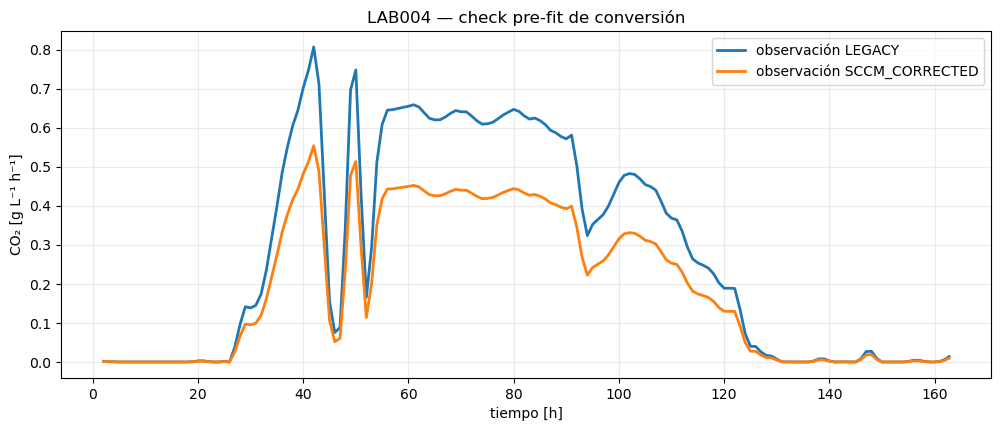

In [6]:
lab004 = old_observations.query("batch == 'LAB004'").sort_values("t_h").copy()
lab004["sccm_equivalente_procesado"] = lab004["co2_rate_g_l_h"] / legacy_factor
lab004["legacy_g_l_h"] = lab004["sccm_equivalente_procesado"] * legacy_factor
lab004["corrected_g_l_h"] = lab004["sccm_equivalente_procesado"] * corrected_factor
t = lab004["t_h"].to_numpy(float)
old_y = lab004["legacy_g_l_h"].to_numpy(float)
new_y = lab004["corrected_g_l_h"].to_numpy(float)
old_peak_i, new_peak_i = int(np.argmax(old_y)), int(np.argmax(new_y))
old_integral, new_integral = np.trapz(old_y, t), np.trapz(new_y, t)
shape_corr = np.corrcoef(old_y / old_y.max(), new_y / new_y.max())[0, 1]
lab004_check = pd.DataFrame({
    "métrica": ["peak", "integral", "peak time", "N timestamps", "máxima diferencia temporal", "correlación forma normalizada"],
    "OLD": [old_y[old_peak_i], old_integral, t[old_peak_i], len(t), 0.0, 1.0],
    "NEW": [new_y[new_peak_i], new_integral, t[new_peak_i], len(t), 0.0, shape_corr],
    "NEW/OLD": [new_y[new_peak_i] / old_y[old_peak_i], new_integral / old_integral, np.nan, 1.0, np.nan, np.nan],
})
display(lab004_check)
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(t, old_y, label="observación LEGACY", lw=2)
ax.plot(t, new_y, label="observación SCCM_CORRECTED", lw=2)
ax.set(xlabel="tiempo [h]", ylabel="CO₂ [g L⁻¹ h⁻¹]", title="LAB004 — check pre-fit de conversión")
ax.grid(alpha=0.25); ax.legend(); plt.show()
assert np.isclose(new_y.max() / old_y.max(), scale_ratio, rtol=1e-12)
assert np.isclose(new_integral / old_integral, scale_ratio, rtol=1e-12)
assert t[old_peak_i] == t[new_peak_i] and shape_corr > 1 - 1e-12

## 7 — Auditoría de máscaras, thresholds y pesos

Tipo A = magnitud física independiente o criterio adimensional; B = asociado inequívocamente al sensor/SCCM; C = origen histórico indeterminado. Para los C se adopta la opción que aísla mejor el factor SCCM y se explicita la limitación. La pasada *native-corrected* aplica literalmente los thresholds históricos a la señal corregida y es sólo descriptiva; el fit usa la máscara frozen.

In [7]:
threshold_audit = pd.DataFrame([
    ["baseline mínimo de excursión", 0.04, "g L^-1 h^-1", "filter_co2_sensor_artifacts (literal)", "C", "congelar decisión OLD", "no altera fit primario"],
    ["acuerdo absoluto de contexto", 0.05, "g L^-1 h^-1", "filter_co2_sensor_artifacts (literal)", "C", "congelar decisión OLD", "evita cambio de artefactos"],
    ["caída transiente mínima", analysis.TRANSIENT_MIN_DROP_G_L_H, "g L^-1 h^-1", "filter_co2_sensor_artifacts", "C", "congelar decisión OLD", "equivale a escalar resultado procesado"],
    ["spike transiente mínimo", analysis.TRANSIENT_MIN_SPIKE_G_L_H, "g L^-1 h^-1", "filter_co2_sensor_artifacts", "C", "congelar decisión OLD", "equivale a escalar resultado procesado"],
    ["LOD estándar", analysis.CO2_DETECTION_LIMIT_G_L_H, "g L^-1 h^-1", "load_co2_data/_fit_residual", "C", "escalar valor; congelar booleano", "mismo SCCM equivalente y misma censura"],
    ["LOD frío", analysis.COLD_CO2_DETECTION_LIMIT_G_L_H, "g L^-1 h^-1", "load_co2_data/_fit_residual", "C", "escalar valor; congelar booleano", "mismo SCCM equivalente y misma censura"],
    ["floor de sigma", analysis.CO2_RESIDUAL_SIGMA_FLOOR_G_L_H, "g L^-1 h^-1", "_profile_matrix_gain/_fit_residual", "C", "escalar por NEW/OLD", "objetivo adimensional comparable"],
    ["sigma proporcional", 0.10, "fracción del peak", "_profile_matrix_gain/_fit_residual", "A", "mantener", "escala automáticamente con la señal"],
    ["sample drop ratio", analysis.SAMPLE_DROP_RATIO, "adimensional", "filter_co2_sensor_artifacts", "A", "mantener", "invariante de escala"],
    ["setpoint frío", analysis.COLD_SETPOINT_THRESHOLD_C, "°C", "load_co2_data", "A", "mantener", "independiente de SCCM"],
    ["onset rango dinámico", analysis.ONSET_DYNAMIC_RANGE_FRACTION, "adimensional", "_onset_threshold", "A", "mantener", "invariante al escalar LOD/baseline"],
    ["primera emisión diagnóstica", analysis.EARLY_EMISSION_THRESHOLD_G_L_H, "g L^-1 h^-1", "_metric_row", "C", "escalar por NEW/OLD", "sólo métrica, no fitting"],
    ["release floor", analysis.CO2_CONTINUOUS_RELEASE_FLOOR, "adimensional", "raw_qgas_grid_prediction", "A", "mantener", "ecuación científica intacta"],
    ["bounds matrix_gain", "0.10–20.0", "adimensional", "PARAMETER_BOUNDS", "A", "mantener", "NEW se perfila dentro de bounds originales"],
], columns=["criterio", "valor", "unidad", "función/ubicación", "tipo A/B/C", "decisión", "efecto"])
display(threshold_audit)

prepared = analysis.prepare_sccm_correction_inputs()
mask_audit_natural = prepared["mask_audit"].query("matrix == 'natural'").reset_index(drop=True)
native_mask_natural = prepared["native_mask_diagnostic"].query("matrix == 'natural'").reset_index(drop=True)
display(mask_audit_natural)
display(native_mask_natural)
assert mask_audit_natural["diferencias de máscara"].sum() == 0
assert mask_audit_natural["timestamps distintos"].sum() == 0

,criterio,valor,unidad,función/ubicación,tipo A/B/C,decisión,efecto
0,baseline mínimo de excursión,0.04,g L^-1 h^-1,filter_co2_sensor_artifacts (literal),C,congelar decisión OLD,no altera fit primario
1,acuerdo absoluto de contexto,0.05,g L^-1 h^-1,filter_co2_sensor_artifacts (literal),C,congelar decisión OLD,evita cambio de artefactos
2,caída transiente mínima,0.05,g L^-1 h^-1,filter_co2_sensor_artifacts,C,congelar decisión OLD,equivale a escalar resultado procesado
3,spike transiente mínimo,0.08,g L^-1 h^-1,filter_co2_sensor_artifacts,C,congelar decisión OLD,equivale a escalar resultado procesado
4,LOD estándar,0.05,g L^-1 h^-1,load_co2_data/_fit_residual,C,escalar valor; congelar booleano,mismo SCCM equivalente y misma censura
5,LOD frío,0.1,g L^-1 h^-1,load_co2_data/_fit_residual,C,escalar valor; congelar booleano,mismo SCCM equivalente y misma censura
6,floor de sigma,0.04,g L^-1 h^-1,_profile_matrix_gain/_fit_residual,C,escalar por NEW/OLD,objetivo adimensional comparable
7,sigma proporcional,0.1,fracción del peak,_profile_matrix_gain/_fit_residual,A,mantener,escala automáticamente con la señal
8,sample drop ratio,0.65,adimensional,filter_co2_sensor_artifacts,A,mantener,invariante de escala
9,setpoint frío,15.5,°C,load_co2_data,A,mantener,independiente de SCCM


,matrix,batch,N raw,N total,N usado OLD,N usado NEW frozen,diferencias de máscara,timestamps distintos
0,natural,LAB004,962,162,97,97,0,0
1,natural,LAB005,962,162,119,119,0,0
2,natural,LAB006,1250,210,139,139,0,0
3,natural,LAB007,960,161,101,101,0,0
4,natural,LAB008,960,161,114,114,0,0
5,natural,LAB010,1100,185,84,84,0,0
6,natural,LAB011,955,161,76,76,0,0
7,natural,LAB012,955,161,98,98,0,0


,matrix,batch,N OLD,N native-corrected,timestamps distintos,censura distinta,estado de artefacto distinto
0,natural,LAB004,162,162,0,1,1
1,natural,LAB005,162,162,0,11,1
2,natural,LAB006,210,210,0,20,1
3,natural,LAB007,161,161,0,6,3
4,natural,LAB008,161,161,0,11,0
5,natural,LAB010,185,185,0,21,0
6,natural,LAB011,161,161,0,4,0
7,natural,LAB012,161,161,0,2,1


## 8 — Recalibración SCCM_CORRECTED

Se optimiza NEW realmente con los mismos batches, theta upstream, parámetros ajustables, bounds, cinco starts, semilla, `least_squares` y profiling analítico de `matrix_gain`. El valor esperado por puro scaling no se pasa al optimizador. La rama sintética se conserva porque comparte la función, pero es secundaria.

In [8]:
result = analysis.run_sccm_correction_fit(
    prepared=prepared, n_starts=5, max_nfev=300, seed=20260812, output_dir=NEW_RESULTS_DIR
)
best_starts = (
    result["fit_starts"].sort_values(["matrix", "wsse_equal_batch"])
    .groupby("matrix", as_index=False).first()
)
fit_execution = best_starts[["matrix", "start", "success", "status", "nfev", "wsse_equal_batch", "matrix_gain", "message"]]
display(fit_execution)
assert fit_execution["success"].all()
assert result["old_results_unchanged"]

,matrix,start,success,status,nfev,wsse_equal_batch,matrix_gain,message
0,natural,3,True,2,37,27.952095,2.139011,`ftol` termination condition is satisfied.
1,synthetic,0,True,2,89,19.515601,1.459910,`ftol` termination condition is satisfied.


## 9 — Parámetros OLD vs NEW

In [9]:
parameter_order = [
    "kCO2_release_h", "CO2sat_scale", "O2_qmax_mg_gdw_h", "O2_initial_scale",
    "pulse_t_rise_h", "pulse_activity_gain", "chem_activation_start_fraction",
    "chem_activation_duration_fraction", "matrix_gain",
]
old_natural = result["old_fit_parameters"].query("calibration_matrix == 'natural'").copy()
new_natural = result["fit_parameters"].query("calibration_matrix == 'natural'").copy()
parameter_compare = old_natural.merge(new_natural, on=["calibration_matrix", "parameter"], suffixes=("_old", "_new"))
parameter_compare["Δ abs"] = parameter_compare["estimate_new"] - parameter_compare["estimate_old"]
parameter_compare["Δ %"] = 100 * parameter_compare["Δ abs"] / parameter_compare["estimate_old"]
parameter_compare["cota OLD"] = parameter_compare["active_bound_old"]
parameter_compare["cota NEW"] = parameter_compare["active_bound_new"]
parameter_compare["_order"] = parameter_compare["parameter"].map({p: i for i, p in enumerate(parameter_order)})
parameter_compare = parameter_compare.sort_values("_order").reset_index(drop=True)
parameter_table = parameter_compare[["parameter", "estimate_old", "estimate_new", "Δ abs", "Δ %", "lower_bound_old", "upper_bound_old", "cota OLD", "cota NEW"]].rename(columns={
    "parameter": "parámetro", "estimate_old": "OLD histórico", "estimate_new": "SCCM_CORRECTED",
    "lower_bound_old": "LB", "upper_bound_old": "UB",
})
display(parameter_table)

,parámetro,OLD histórico,SCCM_CORRECTED,Δ abs,Δ %,LB,UB,cota OLD,cota NEW
0,kCO2_release_h,0.424588,0.424382,-2.062678e-04,-4.858067e-02,0.03,25.00,False,False
1,CO2sat_scale,0.351390,0.350040,-1.349393e-03,-3.840161e-01,0.35,2.50,True,True
2,O2_qmax_mg_gdw_h,0.150000,0.150000,1.029732e-14,6.864879e-12,0.15,6.00,True,True
3,O2_initial_scale,0.195400,0.195484,8.393121e-05,4.295361e-02,0.05,1.50,False,False
4,pulse_t_rise_h,64.658704,64.659221,5.174386e-04,8.002613e-04,1.00,72.00,False,False
5,pulse_activity_gain,0.250000,0.250000,5.551115e-17,2.220446e-14,0.25,4.00,True,True
6,chem_activation_start_fraction,0.735057,0.735179,1.226257e-04,1.668248e-02,0.01,0.95,False,False
7,chem_activation_duration_fraction,1.063910,1.063783,-1.267746e-04,-1.191591e-02,0.35,2.00,False,False
8,matrix_gain,3.115757,2.139011,-9.767460e-01,-3.134860e+01,0.10,20.00,False,False


## 10 — Diagnóstico de matrix_gain

,caso,matrix_gain,diferencia vs expected,diferencia vs expected [%],descenso esperado absorbido [%]
0,OLD HISTÓRICO,3.115757,NaN,NaN,NaN
1,EXPECTED_BY_PURE_SCALING,2.139010,0.000000,0.000000,NaN
2,REFITTED_SCCM_CORRECTED,2.139011,0.000001,0.000047,99.999896


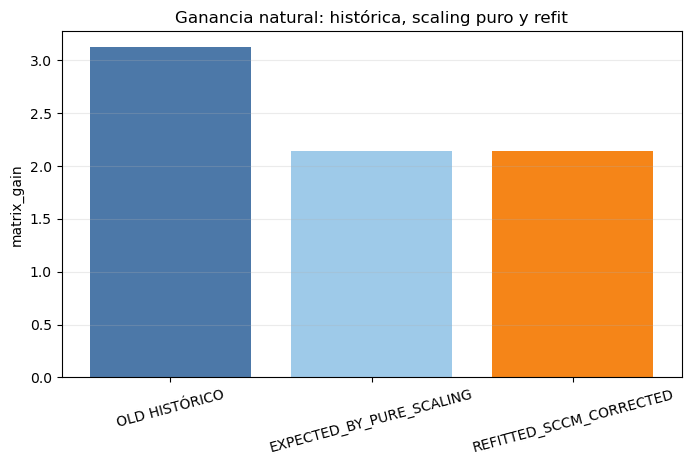

In [10]:
gain_old = float(parameter_compare.loc[parameter_compare["parameter"].eq("matrix_gain"), "estimate_old"].iloc[0])
gain_new = float(parameter_compare.loc[parameter_compare["parameter"].eq("matrix_gain"), "estimate_new"].iloc[0])
gain_expected = gain_old * scale_ratio
gain_difference = gain_new - gain_expected
gain_difference_pct = 100 * gain_difference / gain_expected
gain_absorption_pct = 100 * (gain_old - gain_new) / (gain_old - gain_expected)
gain_table = pd.DataFrame([
    ["OLD HISTÓRICO", gain_old, np.nan, np.nan],
    ["EXPECTED_BY_PURE_SCALING", gain_expected, 0.0, 0.0],
    ["REFITTED_SCCM_CORRECTED", gain_new, gain_difference, gain_difference_pct],
], columns=["caso", "matrix_gain", "diferencia vs expected", "diferencia vs expected [%]"])
gain_table["descenso esperado absorbido [%]"] = [np.nan, np.nan, gain_absorption_pct]
display(gain_table)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(gain_table["caso"], gain_table["matrix_gain"], color=["#4C78A8", "#9ECAE9", "#F58518"])
ax.set(ylabel="matrix_gain", title="Ganancia natural: histórica, scaling puro y refit")
ax.tick_params(axis="x", rotation=15); ax.grid(axis="y", alpha=0.25); plt.show()

## 11 — Curvas OLD vs NEW por batch

Se muestran todos los batches naturales disponibles en la calibración histórica; LAB012 se conserva como holdout interno. El sombreado marca ±12 h alrededor del peak observado LEGACY y la línea vertical punteada indica nutrición cuando corresponde.

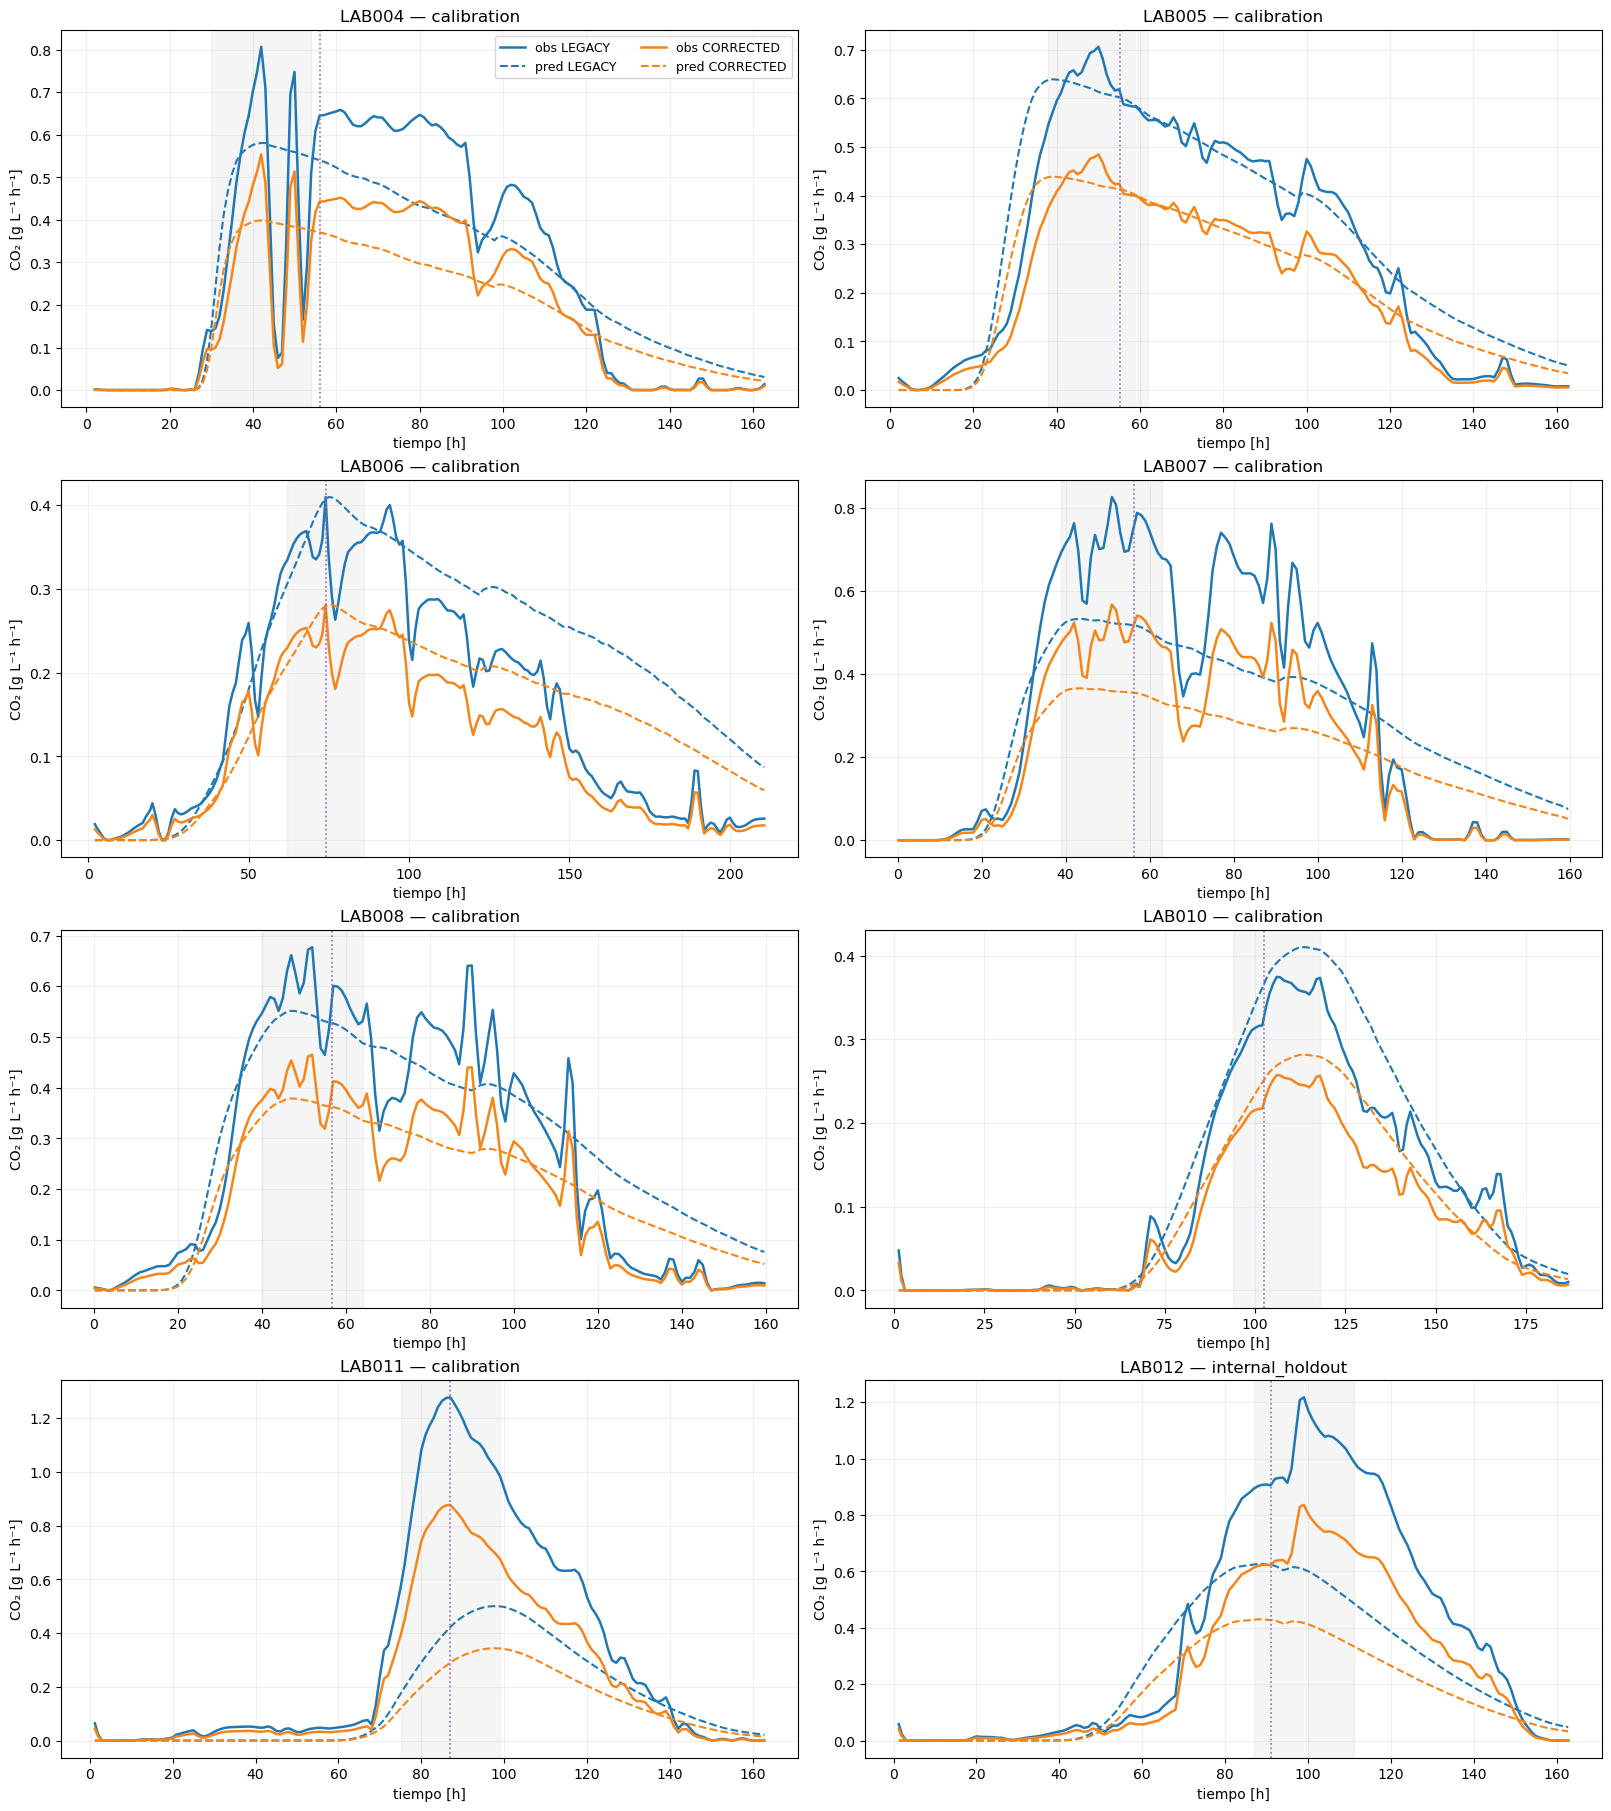

In [11]:
old_pred_nat = result["old_predictions"].query("calibration_matrix == 'natural' and target_matrix == 'natural'").copy()
new_pred_nat = result["predictions"].query("calibration_matrix == 'natural' and target_matrix == 'natural'").copy()
batches_natural = sorted(old_pred_nat["batch"].unique())
fig, axes = plt.subplots(4, 2, figsize=(16, 18), constrained_layout=True)
for ax, batch in zip(axes.flat, batches_natural):
    old = old_pred_nat.query("batch == @batch").sort_values("time_h")
    new = new_pred_nat.query("batch == @batch").sort_values("time_h")
    ax.plot(old["time_h"], old["observed_g_l_h"], color="#1F77B4", lw=1.8, label="obs LEGACY")
    ax.plot(old["time_h"], old["predicted_g_l_h"], color="#1F77B4", ls="--", lw=1.5, label="pred LEGACY")
    ax.plot(new["time_h"], new["observed_g_l_h"], color="#F58518", lw=1.8, label="obs CORRECTED")
    ax.plot(new["time_h"], new["predicted_g_l_h"], color="#F58518", ls="--", lw=1.5, label="pred CORRECTED")
    peak_t = float(old.loc[old["observed_g_l_h"].idxmax(), "time_h"])
    ax.axvspan(peak_t - 12, peak_t + 12, color="grey", alpha=0.08)
    pulse = float(old["pulse_time_h"].dropna().iloc[0]) if old["pulse_time_h"].notna().any() else np.nan
    if np.isfinite(pulse):
        ax.axvline(pulse, color="#9467BD", ls=":", lw=1.2)
    role = str(old["role"].iloc[0])
    ax.set(title=f"{batch} — {role}", xlabel="tiempo [h]", ylabel="CO₂ [g L⁻¹ h⁻¹]")
    ax.grid(alpha=0.2)
axes.flat[0].legend(ncol=2, fontsize=9)
plt.show()

## 12 — Métricas OLD vs NEW por batch

RMSE, MAE y bias son sensibles a escala: una reducción proporcional no implica mejor ajuste. NRMSE/peak, correlación, R² e integral pred/obs permiten comparar forma relativa. `objetivo batch` reconstruye la contribución ponderada usada por el modelo; LAB012 aparece para diagnóstico, pero por ser holdout no entra al objetivo de calibración.

In [12]:
def objective_component(group, sigma_floor):
    group = group.sort_values("time_h")
    observed = group["observed_g_l_h"].to_numpy(float)
    predicted = group["predicted_g_l_h"].to_numpy(float)
    censored = group["left_censored"].astype(bool).to_numpy()
    sigma = max(sigma_floor, 0.10 * float(np.max(observed)))
    components = []
    if (~censored).any():
        components.append((predicted[~censored] - observed[~censored]) / sigma / np.sqrt(len(group)))
    if censored.any():
        limit = group["detection_limit_g_l_h"].to_numpy(float)[censored]
        components.append(np.maximum(predicted[censored] - limit, 0.0) / sigma / np.sqrt(len(group)))
    frame = pd.DataFrame({"t_h": group["time_h"], "co2_rate_g_l_h": observed, "detection_limit_g_l_h": group["detection_limit_g_l_h"]})
    threshold = analysis._onset_threshold(frame)
    observed_onset = analysis._sustained_onset_h(group["time_h"].to_numpy(float), observed, threshold)
    predicted_onset = analysis._sustained_onset_h(group["time_h"].to_numpy(float), predicted, threshold)
    if np.isfinite(observed_onset):
        if not np.isfinite(predicted_onset):
            predicted_onset = float(group["time_h"].max()) + analysis.ONSET_SIGMA_H
        components.append(np.array([(predicted_onset - observed_onset) / analysis.ONSET_SIGMA_H]))
    pulse = float(group["pulse_time_h"].dropna().iloc[0]) if group["pulse_time_h"].notna().any() else np.nan
    observed_peak = analysis._postpulse_peak_time_h(group["time_h"].to_numpy(float), observed, pulse)
    predicted_peak = analysis._postpulse_peak_time_h(group["time_h"].to_numpy(float), predicted, pulse)
    if np.isfinite(observed_peak):
        if not np.isfinite(predicted_peak):
            predicted_peak = min(float(group["time_h"].max()), pulse + analysis.PULSE_PEAK_WINDOW_H)
        components.append(np.array([(predicted_peak - observed_peak) / analysis.PULSE_PEAK_SIGMA_H]))
    residual = np.concatenate(components)
    return float(np.dot(residual, residual))

old_metrics = result["old_batch_metrics"].query("calibration_matrix == 'natural' and target_matrix == 'natural'").copy()
new_metrics = result["batch_metrics"].query("calibration_matrix == 'natural' and target_matrix == 'natural'").copy()
old_obj = pd.Series(
    {batch: objective_component(group, analysis.CO2_RESIDUAL_SIGMA_FLOOR_G_L_H) for batch, group in old_pred_nat.groupby("batch")},
    name="objetivo OLD",
).rename_axis("batch").reset_index()
new_obj = pd.Series(
    {batch: objective_component(group, analysis.CO2_RESIDUAL_SIGMA_FLOOR_G_L_H * scale_ratio) for batch, group in new_pred_nat.groupby("batch")},
    name="objetivo NEW",
).rename_axis("batch").reset_index()
metric_columns = ["batch", "role", "n", "rmse_g_l_h", "mae_g_l_h", "bias_g_l_h", "nrmse_peak", "correlation", "r2", "integral_ratio_pred_over_obs"]
metrics_compare = old_metrics[metric_columns].merge(new_metrics[metric_columns], on=["batch", "role", "n"], suffixes=(" OLD", " NEW"))
metrics_compare = metrics_compare.merge(old_obj, on="batch").merge(new_obj, on="batch")
metrics_compare["Δ NRMSE"] = metrics_compare["nrmse_peak NEW"] - metrics_compare["nrmse_peak OLD"]
metrics_compare["Δ RMSE %"] = 100 * (metrics_compare["rmse_g_l_h NEW"] / metrics_compare["rmse_g_l_h OLD"] - 1)
display(metrics_compare)

,batch,role,n,rmse_g_l_h OLD,mae_g_l_h OLD,bias_g_l_h OLD,nrmse_peak OLD,correlation OLD,r2 OLD,integral_ratio_pred_over_obs OLD,rmse_g_l_h NEW,mae_g_l_h NEW,bias_g_l_h NEW,nrmse_peak NEW,correlation NEW,r2 NEW,integral_ratio_pred_over_obs NEW,objetivo OLD,objetivo NEW,Δ NRMSE,Δ RMSE %
0,LAB004,calibration,97,0.157291,0.127178,-0.052998,0.194948,0.634988,0.325623,0.956651,0.107988,0.087317,-0.036376,0.194959,0.634905,0.325544,0.956660,2.522240,2.522428,1.144894e-05,-31.344596
1,LAB005,calibration,119,0.075453,0.050480,0.019283,0.106871,0.926601,0.848688,1.092687,0.051810,0.034660,0.013241,0.106894,0.926569,0.848624,1.092689,0.968286,0.968579,2.255946e-05,-31.334136
2,LAB006,calibration,139,0.087672,0.070525,0.057446,0.214141,0.777247,0.306259,1.360551,0.060187,0.048416,0.039435,0.214139,0.777237,0.306273,1.360530,4.083992,4.083752,-2.115039e-06,-31.349306
3,LAB007,calibration,101,0.172832,0.148508,-0.104526,0.209016,0.848006,0.388355,0.902200,0.118653,0.101955,-0.071755,0.209018,0.847983,0.388345,0.902202,3.293393,3.293399,1.638136e-06,-31.348090
4,LAB008,calibration,114,0.090616,0.076536,-0.000739,0.133800,0.892337,0.772197,1.065078,0.062209,0.052543,-0.000506,0.133800,0.892335,0.772195,1.065074,9.264899,9.264780,6.514484e-07,-31.348293
5,LAB010,calibration,84,0.052161,0.042838,0.034038,0.139209,0.941305,0.658461,1.153160,0.035804,0.029402,0.023356,0.139189,0.941300,0.658559,1.153068,1.325719,1.325450,-1.996260e-05,-31.358472
6,LAB011,calibration,76,0.443024,0.351992,-0.349040,0.346607,0.826919,-0.371414,0.465974,0.304147,0.241653,-0.239628,0.346612,0.826934,-0.371458,0.465948,6.493567,6.493709,5.572168e-06,-31.347524
7,LAB012,internal_holdout,98,0.318335,0.271367,-0.207234,0.261581,0.776992,0.171016,0.668023,0.218546,0.186302,-0.142275,0.261587,0.776977,0.170979,0.668005,5.281930,5.282196,5.794967e-06,-31.347107


## 13 — Resumen global

In [13]:
calibration_metrics = metrics_compare.query("role == 'calibration'").copy()
old_wsse = float(result["old_fit_starts"].query("matrix == 'natural'")["wsse_equal_batch"].min())
new_wsse = float(result["fits"]["natural"]["wsse_equal_batch"])
summary_specs = [
    ("N observaciones cuantificables", calibration_metrics["n"].sum(), calibration_metrics["n"].sum(), False),
    ("RMSE medio [g L^-1 h^-1]", calibration_metrics["rmse_g_l_h OLD"].mean(), calibration_metrics["rmse_g_l_h NEW"].mean(), True),
    ("MAE medio [g L^-1 h^-1]", calibration_metrics["mae_g_l_h OLD"].mean(), calibration_metrics["mae_g_l_h NEW"].mean(), True),
    ("bias medio [g L^-1 h^-1]", calibration_metrics["bias_g_l_h OLD"].mean(), calibration_metrics["bias_g_l_h NEW"].mean(), True),
    ("NRMSE/peak medio", calibration_metrics["nrmse_peak OLD"].mean(), calibration_metrics["nrmse_peak NEW"].mean(), False),
    ("correlación media", calibration_metrics["correlation OLD"].mean(), calibration_metrics["correlation NEW"].mean(), False),
    ("R² medio", calibration_metrics["r2 OLD"].mean(), calibration_metrics["r2 NEW"].mean(), False),
    ("integral pred/obs media", calibration_metrics["integral_ratio_pred_over_obs OLD"].mean(), calibration_metrics["integral_ratio_pred_over_obs NEW"].mean(), False),
    ("objetivo global equal-batch", old_wsse, new_wsse, False),
]
global_summary = pd.DataFrame(summary_specs, columns=["métrica", "OLD histórico", "SCCM_CORRECTED", "sensible a escala"])
global_summary["Δ"] = global_summary["SCCM_CORRECTED"] - global_summary["OLD histórico"]
global_summary["Δ %"] = 100 * global_summary["Δ"] / global_summary["OLD histórico"].replace(0, np.nan)
display(global_summary)

,métrica,OLD histórico,SCCM_CORRECTED,sensible a escala,Δ,Δ %
0,N observaciones cuantificables,730.000000,730.000000,False,0.000000e+00,0.000000
1,RMSE medio [g L^-1 h^-1],0.154150,0.105828,True,-4.832130e-02,-31.346990
2,MAE medio [g L^-1 h^-1],0.124008,0.085135,True,-3.887321e-02,-31.347288
3,bias medio [g L^-1 h^-1],-0.056648,-0.038890,True,1.775765e-02,-31.347324
4,NRMSE/peak medio,0.192085,0.192087,False,2.827501e-06,0.001472
5,correlación media,0.835343,0.835323,False,-1.981380e-05,-0.002372
6,R² medio,0.418310,0.418298,False,-1.247864e-05,-0.002983
7,integral pred/obs media,0.999472,0.999453,False,-1.860534e-05,-0.001862
8,objetivo global equal-batch,27.952096,27.952095,False,-7.352223e-07,-0.000003


## 14 — Cambio porcentual de parámetros

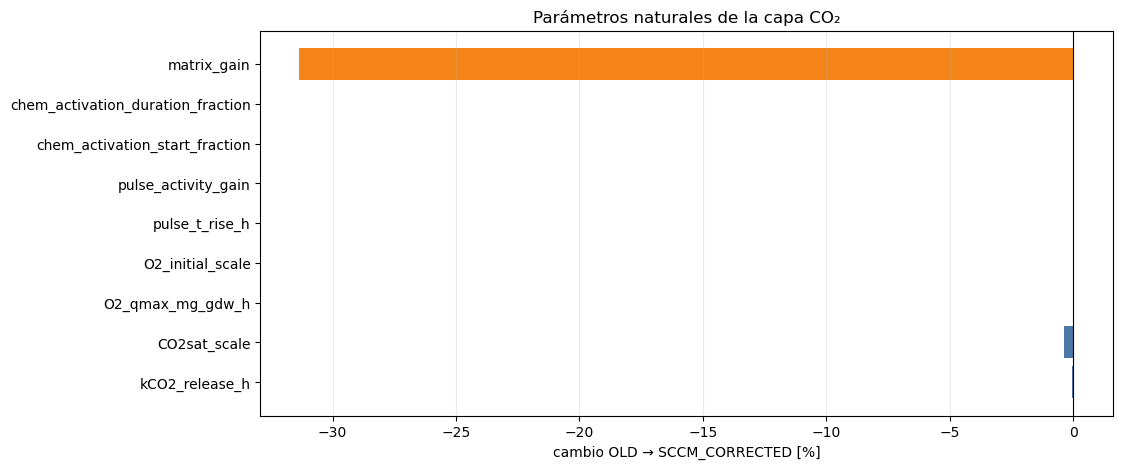

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = np.where(parameter_compare["parameter"].eq("matrix_gain"), "#F58518", "#4C78A8")
ax.barh(parameter_compare["parameter"], parameter_compare["Δ %"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set(xlabel="cambio OLD → SCCM_CORRECTED [%]", title="Parámetros naturales de la capa CO₂")
ax.grid(axis="x", alpha=0.25); plt.show()

## 15 — Descomposición del efecto

In [15]:
dynamic = parameter_compare.query("parameter != 'matrix_gain'").copy()
largest_dynamic = dynamic.loc[dynamic["Δ %"].abs().idxmax()]
decomposition = pd.DataFrame([
    ["A — conversión física directa", scale_ratio, (1-scale_ratio)*100, "observación y cantidades sensor-scale"],
    ["B — matrix_gain", gain_new / gain_old, gain_absorption_pct, "comparación contra descenso esperado"],
    ["C — dinámica", largest_dynamic["parameter"], largest_dynamic["Δ %"], "máximo cambio porcentual absoluto"],
    ["D — thresholds/máscara", int(mask_audit_natural["diferencias de máscara"].sum()), 0.0, "máscara primaria congelada"],
    ["D — sigma/floor", analysis.CO2_RESIDUAL_SIGMA_FLOOR_G_L_H * scale_ratio, scale_ratio, "floor C escalado; peso adimensional comparable"],
], columns=["componente", "resultado", "magnitud [% o conteo]", "lectura"])
display(decomposition)

,componente,resultado,magnitud [% o conteo],lectura
0,A — conversión física directa,0.686514,31.348628,observación y cantidades sensor-scale
1,B — matrix_gain,0.686514,99.999896,comparación contra descenso esperado
2,C — dinámica,CO2sat_scale,-0.384016,máximo cambio porcentual absoluto
3,D — thresholds/máscara,0,0.000000,máscara primaria congelada
4,D — sigma/floor,0.027461,0.686514,floor C escalado; peso adimensional comparable


## 16 — Resultados observados

In [16]:
ranked_dynamic = dynamic.assign(abs_delta_pct=dynamic["Δ %"].abs()).sort_values("abs_delta_pct", ascending=False)
worst_batch = metrics_compare.loc[metrics_compare["Δ NRMSE"].idxmax()]
best_batch = metrics_compare.loc[metrics_compare["Δ NRMSE"].idxmin()]
observed_facts = pd.DataFrame([
    ["factor NEW/OLD", scale_ratio],
    ["reducción de escala [%]", (1-scale_ratio)*100],
    ["diferencias de máscara primaria", int(mask_audit_natural["diferencias de máscara"].sum())],
    ["matrix_gain OLD", gain_old],
    ["matrix_gain esperado", gain_expected],
    ["matrix_gain reestimado", gain_new],
    ["absorción del descenso esperado [%]", gain_absorption_pct],
    ["mayor |Δ dinámico|", f"{largest_dynamic['parameter']}: {largest_dynamic['Δ %']:.6g}%"],
    ["mayor Δ NRMSE (deterioro relativo)", f"{worst_batch['batch']}: {worst_batch['Δ NRMSE']:.6g}"],
    ["menor Δ NRMSE (mejor cambio relativo)", f"{best_batch['batch']}: {best_batch['Δ NRMSE']:.6g}"],
], columns=["hecho", "valor"])
display(observed_facts)

,hecho,valor
0,factor NEW/OLD,0.686514
1,reducción de escala [%],31.348628
2,diferencias de máscara primaria,0
3,matrix_gain OLD,3.115757
4,matrix_gain esperado,2.13901
5,matrix_gain reestimado,2.139011
6,absorción del descenso esperado [%],99.999896
7,mayor |Δ dinámico|,CO2sat_scale: -0.384016%
8,mayor Δ NRMSE (deterioro relativo),LAB005: 2.25595e-05
9,menor Δ NRMSE (mejor cambio relativo),LAB010: -1.99626e-05


## 17 — Interpretación

In [17]:
mean_delta_nrmse = float(metrics_compare["Δ NRMSE"].mean())
max_dynamic_pct = float(ranked_dynamic["abs_delta_pct"].iloc[0])
condition = float(result["jacobian_identifiability"].query("matrix == 'natural'")["condition_number_log_parameter_jacobian"].iloc[0])
active_new = parameter_compare.loc[parameter_compare["cota NEW"].astype(bool), "parameter"].tolist()
absorption_text = "prácticamente todo" if abs(gain_absorption_pct - 100) < 1 else "no todo"
relative_text = "quedó numéricamente equivalente" if abs(mean_delta_nrmse) < 1e-4 else ("mejoró" if mean_delta_nrmse < 0 else "empeoró")
display(Markdown(f'''
- `matrix_gain` absorbió **{absorption_text}** el cambio: {gain_absorption_pct:.6f}% del descenso esperado; NEW difiere del scaling puro en {gain_difference_pct:.6g}%.
- El mayor cambio dinámico fue `{largest_dynamic['parameter']}` ({largest_dynamic['Δ %']:.6g}%); con máscara fija, el máximo |Δ| dinámico fue {max_dynamic_pct:.6g}%.
- La forma/calidad relativa {relative_text}: Δ NRMSE medio = {mean_delta_nrmse:.6g}. El RMSE absoluto cae por escala y no se interpreta como mejora.
- Mayor deterioro relativo por Δ NRMSE: **{worst_batch['batch']}** ({worst_batch['Δ NRMSE']:.6g}); mejor cambio relativo: **{best_batch['batch']}** ({best_batch['Δ NRMSE']:.6g}).
- La identificabilidad local sigue mostrando número de condición {condition:.4g}; parámetros NEW en cota: {', '.join(active_new) if active_new else 'ninguno'}. La compensación de escala y los parámetros en cota son señales de correlación/no-identificabilidad, no evidencia de nueva biología.
- No se puede concluir sobre parámetros upstream, ΔN, theta canónico, causalidad nutricional, LAB013–015 ni desempeño en LAB016–018.
'''))


- `matrix_gain` absorbió **prácticamente todo** el cambio: 99.999896% del descenso esperado; NEW difiere del scaling puro en 4.7288e-05%.
- El mayor cambio dinámico fue `CO2sat_scale` (-0.384016%); con máscara fija, el máximo |Δ| dinámico fue 0.384016%.
- La forma/calidad relativa quedó numéricamente equivalente: Δ NRMSE medio = 3.19843e-06. El RMSE absoluto cae por escala y no se interpreta como mejora.
- Mayor deterioro relativo por Δ NRMSE: **LAB005** (2.25595e-05); mejor cambio relativo: **LAB010** (-1.99626e-05).
- La identificabilidad local sigue mostrando número de condición 129.8; parámetros NEW en cota: CO2sat_scale, O2_qmax_mg_gdw_h, pulse_activity_gain. La compensación de escala y los parámetros en cota son señales de correlación/no-identificabilidad, no evidencia de nueva biología.
- No se puede concluir sobre parámetros upstream, ΔN, theta canónico, causalidad nutricional, LAB013–015 ni desempeño en LAB016–018.


## 18 — Conclusión

In [18]:
display(Markdown(f'''La corrección física reduce la escala observada en {(1-scale_ratio)*100:.4f}%. Con soporte, censura y pesos dimensionalmente equivalentes, `matrix_gain` cambia de {gain_old:.8g} a {gain_new:.8g}, frente a {gain_expected:.8g} esperado por scaling puro, y los parámetros dinámicos cambian como máximo {max_dynamic_pct:.4g}%. Por tanto, este experimento distingue una **corrección necesaria de unidades** de una **mejora estadística**: el descenso del error absoluto por sí solo no mejora el modelo.'''))

La corrección física reduce la escala observada en 31.3486%. Con soporte, censura y pesos dimensionalmente equivalentes, `matrix_gain` cambia de 3.1157569 a 2.1390109, frente a 2.1390099 esperado por scaling puro, y los parámetros dinámicos cambian como máximo 0.384%. Por tanto, este experimento distingue una **corrección necesaria de unidades** de una **mejora estadística**: el descenso del error absoluto por sí solo no mejora el modelo.

## 19 — Pendientes

- **PENDIENTE — parámetros upstream:** `sN`, `qXG`, `qXF`, `sG`, `sF`, `m0`.
- **PENDIENTE — discrepancia nutricional:** ΔN = 0.08 kg/m³ vs ΔN = 0.14 kg/m³.
- **PENDIENTE —** theta upstream completo y canónico.
- **PENDIENTE —** recalibración integral consistente upstream → CO₂.
- **PENDIENTE —** holdout formal LAB016–018; no se ejecutó ni tocó en este experimento.
- **PENDIENTE —** estructura causal de respuesta a nutrición.
- **PENDIENTE —** evaluación upstream incorporando LAB013–015.

In [19]:
source_path = NOTEBOOK_DIR / "co2_sccm_correction_experiment_2026.ipynb"
source_json = json.loads(source_path.read_text(encoding="utf-8"))
source_is_clean = all(
    cell.get("cell_type") != "code"
    or (cell.get("execution_count") is None and cell.get("outputs", []) == [])
    for cell in source_json["cells"]
)
checks = pd.DataFrame([
    ["A factor ratio ≈ 0.6865", np.isclose(scale_ratio, 0.6865, atol=5e-4)],
    ["B LAB004 amplitud/integral", np.isclose(new_y.max()/old_y.max(), scale_ratio) and np.isclose(new_integral/old_integral, scale_ratio)],
    ["B LAB004 tiempos/forma", t[old_peak_i] == t[new_peak_i] and shape_corr > 1-1e-12],
    ["C máscara OLD == NEW", mask_audit_natural["diferencias de máscara"].sum() == 0 and mask_audit_natural["timestamps distintos"].sum() == 0],
    ["D OLD no reoptimizado", result["manifest"]["old_policy"].startswith("read saved")],
    ["E NEW optimizado", fit_execution["success"].all() and len(result["fit_starts"]) == 10],
    ["F matrix_gain perfilado", result["manifest"]["new_policy"].startswith("optimize")],
    ["G resultados OLD intactos", result["old_results_unchanged"]],
    ["H LAB016-018 ausentes", not set(["LAB016", "LAB017", "LAB018"]) & set(result["predictions"]["batch"])],
    ["J SOURCE limpio", source_is_clean],
    ["N optimización sin error", fit_execution["success"].all()],
], columns=["check", "OK"])
display(checks)
assert checks["OK"].all()
display(pd.DataFrame({"artefacto secundario": sorted(p.name for p in NEW_RESULTS_DIR.iterdir() if p.is_file())}))

,check,OK
0,A factor ratio ≈ 0.6865,True
1,B LAB004 amplitud/integral,True
2,B LAB004 tiempos/forma,True
3,C máscara OLD == NEW,True
4,D OLD no reoptimizado,True
5,E NEW optimizado,True
6,F matrix_gain perfilado,True
7,G resultados OLD intactos,True
8,H LAB016-018 ausentes,True
9,J SOURCE limpio,True


,artefacto secundario
0,activation_jacobian_identifiability.csv
1,activation_jacobian_singular_values.csv
2,activation_local_parameter_correlations.csv
3,analysis_manifest.json
4,batch_metrics.csv
5,co2_observations_hourly.csv
6,fit_parameters.csv
7,fit_start_diagnostics.csv
8,frozen_mask_audit.csv
9,native_corrected_mask_diagnostic.csv
